## Manufacturer Analysis

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/car_details.csv')

### Missing Values

---

In [6]:
database_length = len(df)
manufacturer_missing_count = df['manufacturer'].isna().sum()


basic_info_df = pd.DataFrame({
    'Total Cars': [database_length],
    'Missing Manufacturer': [manufacturer_missing_count],
    'Missing Manufacturer %': [f'{(manufacturer_missing_count/database_length)*100:.2f}%']
})

display(basic_info_df.style.hide(axis='index'))

Total Cars,Missing Manufacturers,Missing Manufacturer %
106447,0,0.00%


### Unique Manufacturers

Checking out the manufacurers and how many cars they have in the dataset

---

In [10]:
manufacturer_unique_count = df['manufacturer'].nunique()
manufacturer_unique_count_df = pd.DataFrame({
    'Unique Manufacturers' : [manufacturer_unique_count]
})
display(manufacturer_unique_count_df.style.hide(axis='index'))

manufacturer_unique_values = df['manufacturer'].value_counts()
manufacturer_unique_df = pd.DataFrame({
    'Manufacturer': manufacturer_unique_values.index,
    'Car Count': manufacturer_unique_values.values,
    '%': (manufacturer_unique_values.values / len(df) * 100).round(2)
})

pd.set_option("display.max_rows", None)
display(manufacturer_unique_df)

Unique Manufacturers
155


,Manufacturer,Car Count,%
0,VOLKSWAGEN,9628,9.04
1,FORD,8571,8.05
2,BMW,8179,7.68
3,OPEL,8082,7.59
4,MERCEDES-BENZ,7738,7.27
5,AUDI,6081,5.71
6,SKODA,4782,4.49
7,TOYOTA,4732,4.45
8,RENAULT,4087,3.84
9,SUZUKI,3781,3.55


## Threshholds

- Looking to remove rare manufacturers, because they are crucial in determining price
- Manufacturers with few cars will be just noise anyway

*Probably going to remove manufacturers with < 10 cars overall, negligigble amount of data*
 
---

Threshold,Manufacturers Removed,Manufacturers Kept,Cars Removed,Cars Kept,Data Lost %
0,0,155,0,106447,0.00%
5,58,97,95,106352,0.09%
10,68,87,160,106287,0.15%
15,79,76,285,106162,0.27%
20,85,70,381,106066,0.36%
25,90,65,488,105959,0.46%
30,92,63,544,105903,0.51%


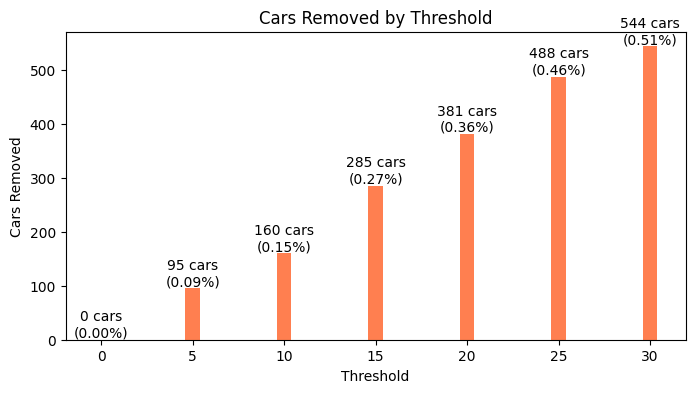

In [5]:
manufacturer_counts = df['manufacturer'].value_counts()
threshold_data = []

for threshold in [0,5, 10, 15, 20, 25, 30]:
    mask = manufacturer_counts < threshold
    
    threshold_data.append({
        'Threshold': threshold,
        'Manufacturers Removed': mask.sum(),
        'Manufacturers Kept': (~mask).sum(),
        'Cars Removed': manufacturer_counts[mask].sum(),
        'Cars Kept': manufacturer_counts[~mask].sum(),
        'Data Lost %': f'{(manufacturer_counts[mask].sum()/len(df)*100):.2f}%'
    })

threshold_df = pd.DataFrame(threshold_data)
display(threshold_df.style.hide(axis='index'))



fig, ax = plt.subplots(figsize=(8,4))
ax.bar(threshold_df['Threshold'], threshold_df['Cars Removed'], color='coral')
ax.set_xlabel('Threshold')
ax.set_ylabel('Cars Removed')
ax.set_title('Cars Removed by Threshold')

# %
for i in range(len(threshold_df)):
    ax.text(threshold_df['Threshold'][i], 
            threshold_df['Cars Removed'][i], 
            f'{threshold_df["Cars Removed"][i]} cars\n({threshold_df["Data Lost %"][i]})',  
            ha='center', va='bottom')
plt.show()